In [7]:
import random
from collections import deque
import math
from tqdm import tqdm

def build_layered_dag(level_sizes, out_degree):
    """
    レベル付き DAG を生成する。

    level_sizes: 各レベルの頂点数のリスト [n0, n1, ..., nL-1]
    out_degree:  最終レベル以外の各頂点の出次数（固定）

    レベル l の頂点集合は，連番 ID の区間 [offset[l], offset[l+1]) に対応。
    辺は常に level l → level l+1 にだけ張るので DAG になる。
    """
    assert len(level_sizes) >= 2, "レベル数は少なくとも 2"
    num_levels = len(level_sizes)

    # 各レベルの開始インデックスを作る
    offset = [0] * (num_levels + 1)
    for i in range(num_levels):
        offset[i + 1] = offset[i] + level_sizes[i]

    n = offset[-1]  # 全頂点数
    adj = [[] for _ in range(n)]


    for lvl in range(num_levels - 1):
        curr_begin = offset[lvl]
        curr_end   = offset[lvl + 1]
        next_begin = offset[lvl + 1]
        next_end   = offset[lvl + 2]

        curr_nodes = range(curr_begin, curr_end)
        next_nodes = list(range(next_begin, next_end))

        # 固定出次数 out_degree を満たすには、次レベルの頂点数が十分必要
        if out_degree > len(next_nodes):
            raise ValueError(
                f"レベル {lvl} → {lvl+1} の遷移で "
                f"out_degree={out_degree} に対して次レベルの頂点数が不足しています: {len(next_nodes)}"
            )

        for u in curr_nodes:
            # 次レベルから out_degree 個の異なる頂点を選ぶ
            adj[u] = random.sample(next_nodes, out_degree)

    # 始点: レベル0の先頭
    s = offset[0]  # = 0
    # 終点: 最終レベルからランダムに選ぶ
    t = random.randint(offset[num_levels - 1], offset[num_levels]-1)

    return adj, s, t, offset


def count_num_shortest_paths(adj, s, t):
    """
    有向グラフ adj 上で，
    s -> t の最短距離とその本数を求める（辺重みはすべて 1）。
    到達不能なときは (None, 0) を返す。
    """
    n = len(adj)
    INF = 10**18
    dist = [INF] * n
    ways = [0] * n

    dist[s] = 0
    ways[s] = 1

    q = deque([s])
    while q:
        u = q.popleft()
        for v in adj[u]:
            # 初めて到達
            if dist[v] == INF:
                dist[v] = dist[u] + 1
                ways[v] = ways[u]
                q.append(v)
            # 同じ長さの別の最短経路が見つかった
            elif dist[v] == dist[u] + 1:
                ways[v] += ways[u]

    if dist[t] == INF:
        return None, 0
    return dist[t], ways[t]

def combination(n, r):
    return math.factorial(n) // (math.factorial(r) * math.factorial(n - r))

if __name__ == "__main__":
    # 例:
    r = 15
    level_sizes = [1, 
                   1+r, 
                   1+r+combination(r, 2),
                   1+r+combination(r, 2)+combination(r, 3),
                   1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)]
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5),]
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6),
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)]
                   #1+r+combination(r, 2)+combination(r, 3)+combination(r, 4)+combination(r, 5)+combination(r, 6)+combination(r, 7)+combination(r, 8)] 
    out_degree = r  # 各頂点の出次数（最終レベル以外）

    num_path_list = []
    all_path_list = []
    efficiency_list = []
    for _ in tqdm(range(10)):
        adj, s, t, offset = build_layered_dag(level_sizes, out_degree)

        dist, num_paths = count_num_shortest_paths(adj, s, t)

        num_path_list.append(num_paths)
        all_path_list.append(r**(len(level_sizes)-2))
        efficiency_list.append(num_paths / r**(len(level_sizes)-2) * 100)
        #print(f"num_nodes = {len(adj)}")
        #print(f"start = {s} (level 0), goal = {t} (last level)")
        #print("shortest distance:", dist)
        #print("number of shortest paths:", num_paths)
        #print("number of all paths:", r**(len(level_sizes)-2))
        #print("Sampling efficiency:", num_paths / r**(len(level_sizes)-2) * 100, "%")

    print("Average number of shortest paths:", sum(num_path_list)/len(num_path_list))
    print("Average number of all paths:", sum(all_path_list)/len(all_path_list))
    print("Average sampling efficiency:", sum(efficiency_list)/len(efficiency_list), "%")
    # 必要なら隣接リストを確認
    # for u, nbrs in enumerate(adj):
    #     print(u, "->", nbrs)

100%|██████████| 10/10 [00:00<00:00, 122.75it/s]

Average number of shortest paths: 28.7
Average number of all paths: 3375.0
Average sampling efficiency: 0.8503703703703703 %


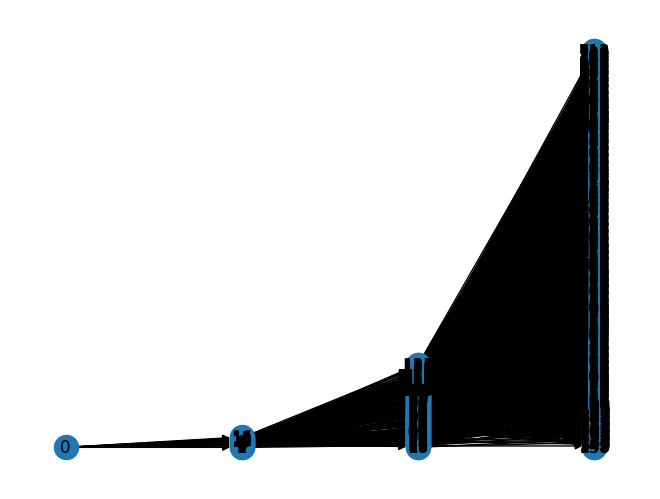

In [ ]:
# networkxで可視化（階層4くらいまでが限界）
import networkx as nx
from matplotlib import pyplot as plt
G = nx.DiGraph()
for u, nbrs in enumerate(adj):
    for v in nbrs:
        G.add_edge(u, v)
# posをoffsetに従って設定
pos = {}
node_id = 0
for level_idx, num_nodes_in_level in enumerate(level_sizes):
    for node_in_level in range(num_nodes_in_level):
        pos[node_id] = (level_idx, node_in_level)
        node_id += 1

nx.draw(G, pos=pos, with_labels=True)
plt.show()